# Phase 4: Model Training & Evaluation

## Objective
In this phase, we aim to build a machine learning classifier to predict the sentiment of professor reviews automatically. 
We will follow these steps as outlined in the project roadmap:

1. **Data Preparation**: Load the cleaned dataset and split it into training and testing sets.
2. **Feature Engineering**: Convert text data into numerical vectors using **TF-IDF** (Term Frequency-Inverse Document Frequency).
3. **Model Training**: Train three distinct supervised learning algorithms:
    - **Naive Bayes (MultinomialNB)**: A probabilistic baseline.
    - **Logistic Regression**: A robust linear model.
    - **Support Vector Machine (SVM)**: Effective for high-dimensional text data.
4. **Evaluation**: Compare models using Accuracy, F1-Score, and Confusion Matrices.
5. **Selection**: Save the best-performing model for future inference.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Sklearn Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Plot settings
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

## 4.1 Data Loading & Splitting

We load the `cleaned_reviews.csv` file generated in the previous phase. We will use `comment_text` as our input feature ($X$) and `sentiment_label` as our target variable ($y$).

In [34]:
# Load data
df = pd.read_csv('../data/processed/cleaned_reviews.csv')

# Drop rows with missing values in critical columns
df = df.dropna(subset=['comment_text', 'sentiment_label'])

# Define Features (X) and Target (y)
X = df['comment_text']
y = df['sentiment_label']

# Check class distribution
print("Class Distribution:")
print(y.value_counts())

Class Distribution:
sentiment_label
recommended        2436
no_idea            1000
not_recommended     839
Name: count, dtype: int64


### Train-Test Split
We split the data into **80% training** and **20% testing** sets to ensure the model is evaluated on unseen data.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensure class balance is maintained in split
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 3420
Testing samples: 855


## 4.2 Feature Engineering (TF-IDF)

Machine learning models cannot understand raw text. We convert the text into numerical vectors using **TF-IDF**.
* **min_df=5**: Ignore terms that appear in fewer than 5 documents (noise reduction).
* **ngram_range=(1, 2)**: Use both unigrams (single words) and bigrams (pairs of words) to capture context.

In [36]:
vectorizer = TfidfVectorizer(min_df=5, ngram_range=(1, 2))

# Fit on training data ONLY, then transform both
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Vocabulary size: 6744


## 4.3 Model Training

We will train three different classifiers to see which architecture performs best on this Persian dataset.

1.  **Naive Bayes**: Fast and effective for text classification.
2.  **Logistic Regression**: Finds a linear boundary between classes.
3.  **SVM (LinearSVC)**: Maximizes the margin between classes.

In [37]:
# Initialize models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": LinearSVC(dual=True, class_weight='balanced')
}

# Dictionary to store results
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"--- Training {name} ---")
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (Weighted): {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    return {
        "model": model,
        "accuracy": acc,
        "f1_score": f1,
        "y_pred": y_pred
    }

In [38]:
# Loop through models and evaluate
for name, clf in models.items():
    results[name] = evaluate_model(name, clf, X_train_tfidf, y_train, X_test_tfidf, y_test)

--- Training Naive Bayes ---
Accuracy: 0.7240
F1 Score (Weighted): 0.6700

Classification Report:
                  precision    recall  f1-score   support

        no_idea       0.92      0.60      0.73       200
not_recommended       1.00      0.12      0.21       168
    recommended       0.68      0.98      0.80       487

       accuracy                           0.72       855
      macro avg       0.87      0.57      0.58       855
   weighted avg       0.80      0.72      0.67       855

--- Training Logistic Regression ---
Accuracy: 0.8012
F1 Score (Weighted): 0.8008

Classification Report:
                  precision    recall  f1-score   support

        no_idea       0.97      0.61      0.75       200
not_recommended       0.63      0.80      0.71       168
    recommended       0.83      0.88      0.85       487

       accuracy                           0.80       855
      macro avg       0.81      0.77      0.77       855
   weighted avg       0.82      0.80      0.80  

## 4.4 Comparative Analysis

We visualize the performance differences to select the best model. The **F1-Score** is prioritized as it balances precision and recall, which is crucial for imbalanced sentiment classes.

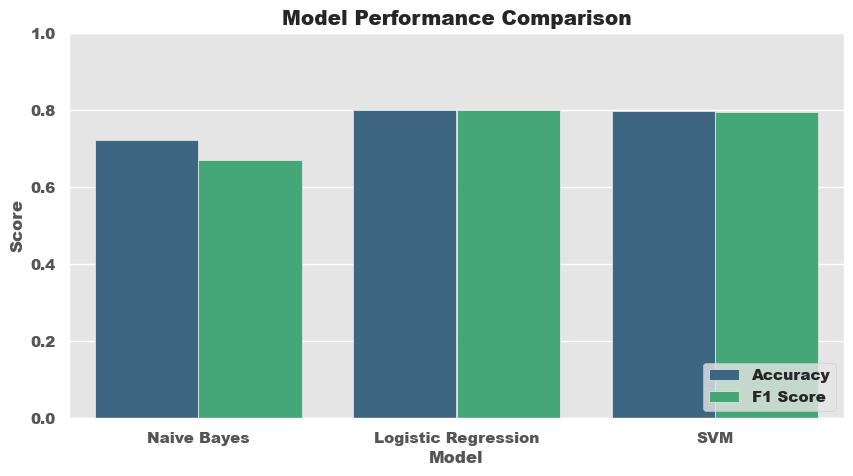

In [39]:
# Create DataFrame for comparison
metrics_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": [res['accuracy'] for res in results.values()],
    "F1 Score": [res['f1_score'] for res in results.values()]
})

# Melt for plotting
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

### Confusion Matrix of the Best Model
Let's visualize where the best model (usually SVM or Logistic Regression in text tasks) makes mistakes.

🏆 The best performing model is: Logistic Regression


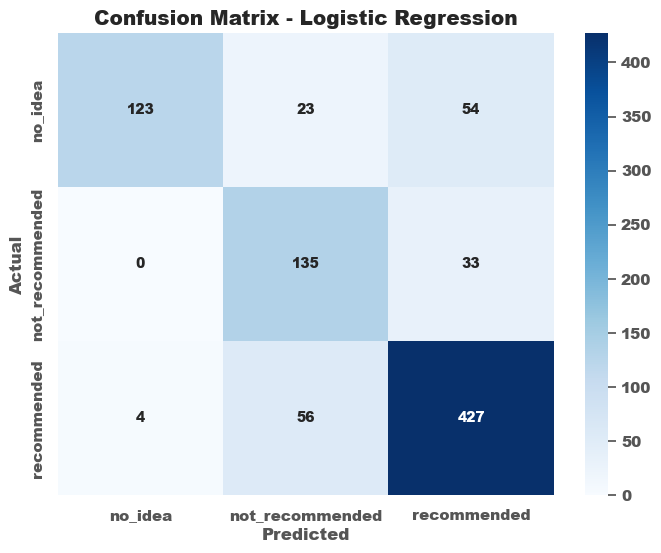

In [40]:
# Find best model based on F1 Score
best_model_name = metrics_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
print(f"🏆 The best performing model is: {best_model_name}")

# Get predictions of the best model
best_preds = results[best_model_name]['y_pred']

# Plot Confusion Matrix
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 4.5 Save Artifacts

We save the vectorizer and the best model to the `models/` directory. This allows us to use the model later for making predictions on new data without retraining.

In [54]:
!pip install arabic-reshaper python-bidi


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


📊 Feature Importance for Logistic Regression:


C:\Users\user\AppData\Local\Temp\ipykernel_33440\2971206781.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature_display', data=top_positive, palette='viridis')


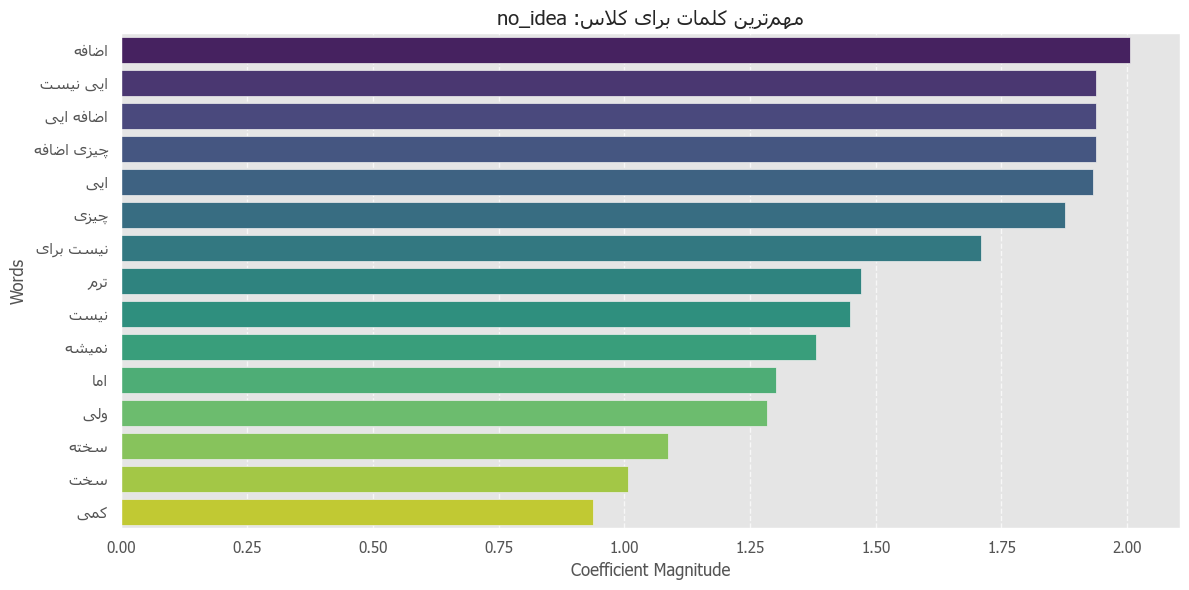


🔹 Top predictors for 'no_idea' (Raw Text):
['اضافه', 'ایی نیست', 'اضافه ایی', 'چیزی اضافه', 'ایی', 'چیزی', 'نیست برای', 'ترم', 'نیست', 'نمیشه', 'اما', 'ولی', 'سخته', 'سخت', 'کمی']
--------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_33440\2971206781.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature_display', data=top_positive, palette='viridis')


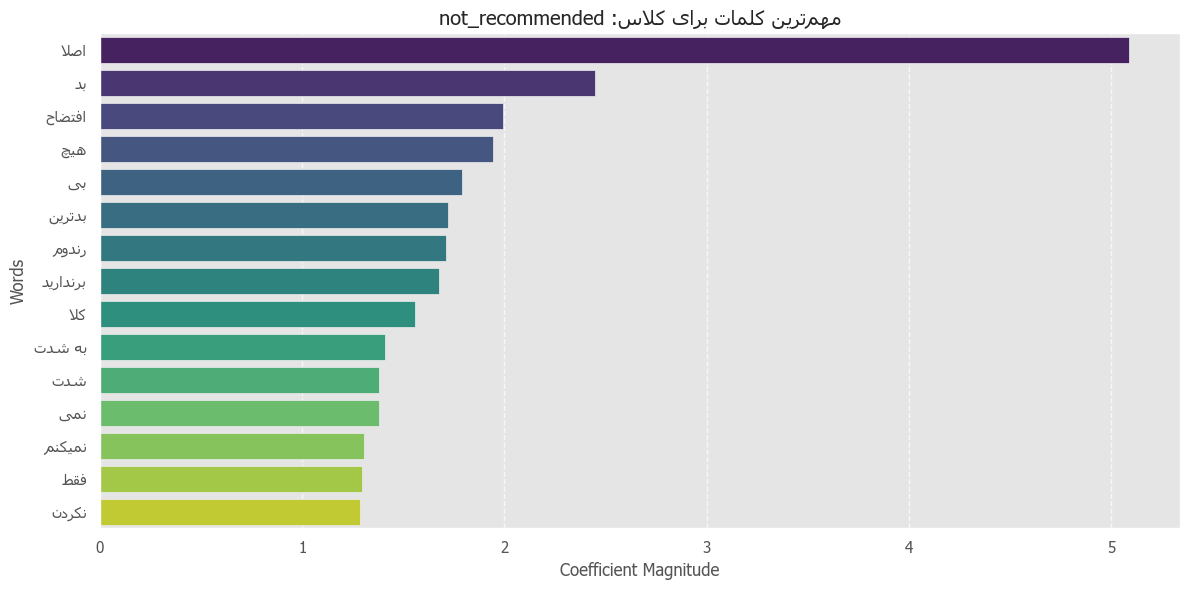


🔹 Top predictors for 'not_recommended' (Raw Text):
['اصلا', 'بد', 'افتضاح', 'هیچ', 'بی', 'بدترین', 'رندوم', 'برندارید', 'کلا', 'به شدت', 'شدت', 'نمی', 'نمیکنم', 'فقط', 'نکردن']
--------------------------------------------------


C:\Users\user\AppData\Local\Temp\ipykernel_33440\2971206781.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature_display', data=top_positive, palette='viridis')


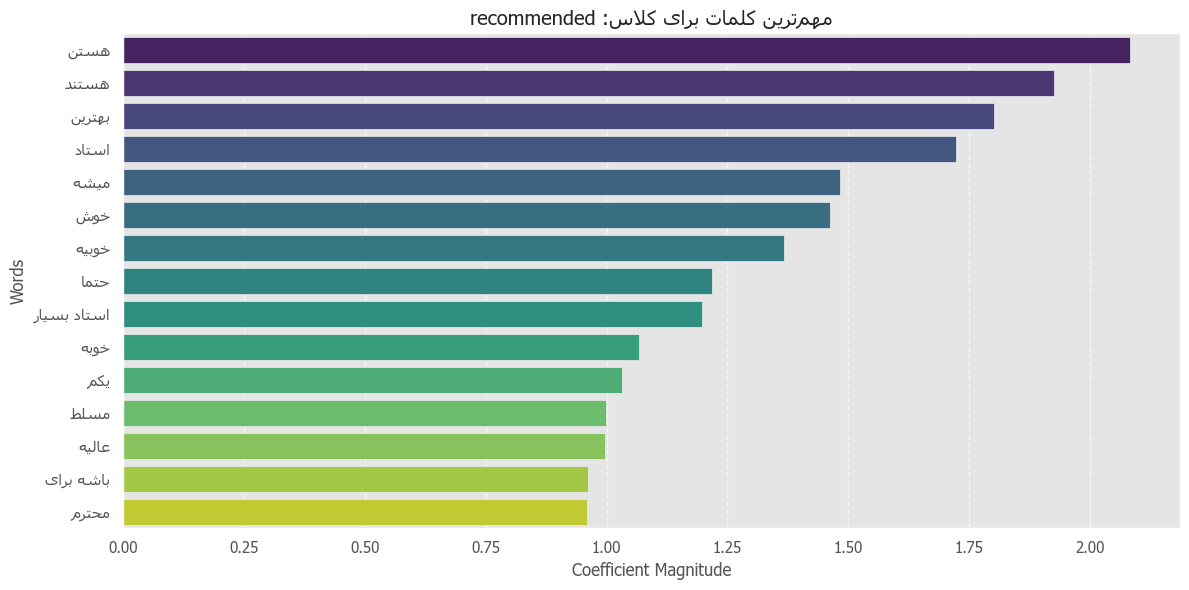


🔹 Top predictors for 'recommended' (Raw Text):
['هستن', 'هستند', 'بهترین', 'استاد', 'میشه', 'خوش', 'خوبیه', 'حتما', 'استاد بسیار', 'خوبه', 'یکم', 'مسلط', 'عالیه', 'باشه برای', 'محترم']
--------------------------------------------------


In [55]:
## 4.4.1 Feature Importance Analysis (Corrected for Persian Display)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

# تنظیم فونت برای پشتیبانی از فارسی (در ویندوز معمولاً Tahoma یا Arial کار می‌کند)
# اگر در لینوکس یا کولب هستید ممکن است نیاز به آپلود فونت داشته باشید
plt.rcParams['font.family'] = 'Tahoma' 

def make_farsi_text(text):
    """
    Reshapes and reorders Persian text for correct display in Matplotlib.
    """
    if not isinstance(text, str):
        return str(text)
    reshaped_text = arabic_reshaper.reshape(text)  # Fix letter connections
    bidi_text = get_display(reshaped_text)         # Fix Right-to-Left direction
    return bidi_text

def plot_feature_importance(model, vectorizer, top_n=15):
    feature_names = vectorizer.get_feature_names_out()
    
    if not hasattr(model, 'coef_'):
        print("⚠️ The selected model does not provide direct feature coefficients.")
        return

    classes = model.classes_
    coefficients = model.coef_
    
    for i, class_label in enumerate(classes):
        if coefficients.shape[0] == 1: 
            coefs = coefficients[0]
            if i == 0: continue 
        else:
            coefs = coefficients[i]

        feat_df = pd.DataFrame({
            'feature': feature_names,
            'coef': coefs
        })
        
        # Sort and get top features
        top_positive = feat_df.sort_values(by='coef', ascending=False).head(top_n).copy()
        
        # --- FIX: Apply Persian Reshaping here ---
        top_positive['feature_display'] = top_positive['feature'].apply(make_farsi_text)
        
        plt.figure(figsize=(12, 6)) # کمی عرض را بیشتر کردیم
        
        # Use 'feature_display' for the Y-axis labels
        sns.barplot(x='coef', y='feature_display', data=top_positive, palette='viridis')
        
        plt.title(make_farsi_text(f"مهم‌ترین کلمات برای کلاس: {class_label}"))
        plt.xlabel("Coefficient Magnitude")
        plt.ylabel("Words")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print(f"\n🔹 Top predictors for '{class_label}' (Raw Text):")
        print(top_positive['feature'].tolist())
        print("-" * 50)

# ---------------------------------------------------------
# اجرا روی مدل
target_model_name = 'Logistic Regression' 

if target_model_name in results:
    print(f"📊 Feature Importance for {target_model_name}:")
    model = results[target_model_name]['model']
    plot_feature_importance(model, vectorizer)
else:
    print(f"Model {target_model_name} not found in results.")